In [1]:
import torchvision
import torch
import random
from torchvision import datasets, transforms
from torchvision.transforms import Compose, Grayscale, ToTensor, Normalize, Lambda
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = Compose([
    Grayscale(),
    ToTensor(),
    Normalize((0,), (1,)),
    Lambda(lambda x: torch.flatten(x))])
trainDataset = datasets.MNIST(root="./data", train=True, download=True,transform = transform)
testDataset  = datasets.MNIST(root="./data", train=False, download=True,transform = transform)

trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=True)
testLoader = DataLoader(testDataset, batch_size=64, shuffle=False)

print(trainDataset)
print(testDataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               ToTensor()
               Normalize(mean=(0,), std=(1,))
               Lambda()
           )
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               ToTensor()
               Normalize(mean=(0,), std=(1,))
               Lambda()
           )


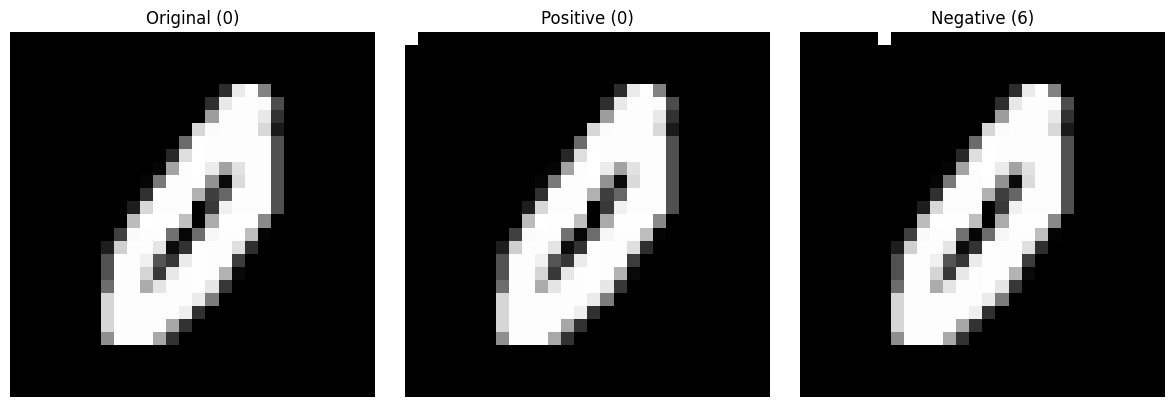

In [2]:
def LabelData(x, y):
    x_ = x.clone()
    x_[:10] *= 0.0
    x_[y] = x.max()
    return x_

def VisualizeData(original, positive, negative, trueLabel, wrongLabel):
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    ax[0].imshow(original.cpu().reshape(28, 28), cmap="gray")
    ax[0].set_title(f"Original ({trueLabel})")
    ax[0].axis("off")

    ax[1].imshow(positive.cpu().reshape(28, 28), cmap="gray")
    ax[1].set_title(f"Positive ({trueLabel})")
    ax[1].axis("off")

    ax[2].imshow(negative.cpu().reshape(28, 28), cmap="gray")
    ax[2].set_title(f"Negative ({wrongLabel})")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

x, y = next(iter(trainLoader))
img = x[1].view(-1)
trueLabel = y[1].item()
wrongLabel = random.choice([i for i in range(10) if i != trueLabel])

xPositive = LabelData(img, trueLabel)
xNegative = LabelData(img, wrongLabel)
VisualizeData(img, xPositive, xNegative, trueLabel, wrongLabel)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FFLayer(nn.Linear):
    def __init__(self, in_features, out_features, threshold=2.0):
        super().__init__(in_features, out_features)
        self.relu = nn.ReLU()
        self.threshold = threshold
    def forward(self, x):
        #Normalize input by peers
        x = x / (x.norm(2, dim=1, keepdim=True) + 1e-4)
        return self.relu(super().forward(x))
    def goodness(self, x):
        return self.forward(x).pow(2).mean(dim=1)

class FFNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.ModuleList([
            FFLayer(784, 500),
            FFLayer(500, 500),
            FFLayer(500, 500)
        ])

    def forward(self, x):
        x = x.view(x.size(0), -1)
        for layer in self.layers:
            x = layer(x)
        return x
model = FFNet()
print(model)

FFNet(
  (layers): ModuleList(
    (0): FFLayer(
      in_features=784, out_features=500, bias=True
      (relu): ReLU()
    )
    (1-2): 2 x FFLayer(
      in_features=500, out_features=500, bias=True
      (relu): ReLU()
    )
  )
)


In [4]:
import torch
import torch.nn.functional as F
import random
def BatchPositiveNegative(x, y):
    x = x.view(x.size(0), -1)
    xPositive = []
    xNegative = []
    for i in range(x.size(0)):
        yi = y[i].item()
        wrong = random.choice([k for k in range(10) if k != yi])
        xPositive.append(LabelData(x[i], yi))
        xNegative.append(LabelData(x[i], wrong))
    return torch.stack(xPositive), torch.stack(xNegative)
def ForwardThroughLayers(model, x, upto):
    x = x.view(x.size(0), -1)
    #Ensure gradients are not passed
    with torch.no_grad():
        for i in range(upto):
            x = model.layers[i](x)
    return x
def TrainSingleLayer(layer, optimizer, xPositive, xNegative, threshold=2.0):
    goodnessPositive = layer.goodness(xPositive)
    goodnessNegative = layer.goodness(xNegative)
    loss = torch.log(1 + torch.exp(torch.cat([-(goodnessPositive - threshold),(goodnessNegative - threshold)]))).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()
def TrainForwardForward(model, loader, epochs=1, lr=0.01):
    for li, layer in enumerate(model.layers):
        optimizer = torch.optim.Adam(layer.parameters(), lr=lr)
        print(f"\nTraining layer {li}")
        for epoch in range(epochs):
            total_loss = 0
            for x, y in loader:
                #propagate input through previous layers
                x = ForwardThroughLayers(model, x, li)
                xPositive, xNegative = BatchPositiveNegative(x, y)
                loss = TrainSingleLayer(layer, optimizer, xPositive, xNegative)
                total_loss += loss
            print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

In [5]:
TrainForwardForward(model, trainLoader, epochs=5, lr=0.01)


Training layer 0
Epoch 1, Loss: 0.6639
Epoch 2, Loss: 0.4988
Epoch 3, Loss: 0.3953
Epoch 4, Loss: 0.3363
Epoch 5, Loss: 0.2978

Training layer 1
Epoch 1, Loss: 0.5249
Epoch 2, Loss: 0.3013
Epoch 3, Loss: 0.2390
Epoch 4, Loss: 0.2060
Epoch 5, Loss: 0.1858

Training layer 2
Epoch 1, Loss: 0.4929
Epoch 2, Loss: 0.2599
Epoch 3, Loss: 0.2062
Epoch 4, Loss: 0.1816
Epoch 5, Loss: 0.1685


In [9]:
def Predict(model, x):
    x = x.view(-1)
    bestLabel = None
    bestScore = -1e9
    #Try all possible labels for each input, correct label should output highest score
    for label in range(10):
        xLabeled = LabelData(x.clone(), label).unsqueeze(0)
        totalScore = 0.0
        h = xLabeled
        for layer in model.layers:
            h = layer(h)
            totalScore += h.pow(2).mean().item()
        if totalScore > bestScore:
            bestScore = totalScore
            bestLabel = label
    return bestLabel

def Accuracy(model, testLoader):
    correct = 0
    total = 0
    for batchIndex, (x, y) in enumerate(testLoader):
        for i in range(x.size(0)):
            prediction = Predict(model, x[i])
            if prediction == y[i].item():
                correct += 1
            total += 1
        #Running accuracy after each batch
        print(f"Batch {batchIndex+1} | Running accuracy: {correct / total:.4f}")
    return correct / total

accuracy = Accuracy(model, testLoader)
print("Test accuracy:", accuracy)

Batch 1 | Running accuracy: 0.9844
Batch 2 | Running accuracy: 0.9531
Batch 3 | Running accuracy: 0.9479
Batch 4 | Running accuracy: 0.9414
Batch 5 | Running accuracy: 0.9406
Batch 6 | Running accuracy: 0.9349
Batch 7 | Running accuracy: 0.9330
Batch 8 | Running accuracy: 0.9219
Batch 9 | Running accuracy: 0.9219
Batch 10 | Running accuracy: 0.9141
Batch 11 | Running accuracy: 0.9105
Batch 12 | Running accuracy: 0.9076
Batch 13 | Running accuracy: 0.9111
Batch 14 | Running accuracy: 0.9096
Batch 15 | Running accuracy: 0.9062
Batch 16 | Running accuracy: 0.9053
Batch 17 | Running accuracy: 0.9044
Batch 18 | Running accuracy: 0.9036
Batch 19 | Running accuracy: 0.8972
Batch 20 | Running accuracy: 0.8930
Batch 21 | Running accuracy: 0.8884
Batch 22 | Running accuracy: 0.8913
Batch 23 | Running accuracy: 0.8893
Batch 24 | Running accuracy: 0.8880
Batch 25 | Running accuracy: 0.8869
Batch 26 | Running accuracy: 0.8876
Batch 27 | Running accuracy: 0.8866
Batch 28 | Running accuracy: 0.8867
B